ε = 0.0 | Recompensa Total = 19.417
ε = 0.2 | Recompensa Total = 20.493
ε = 0.5 | Recompensa Total = 20.797
ε = 1.0 | Recompensa Total = 17.318


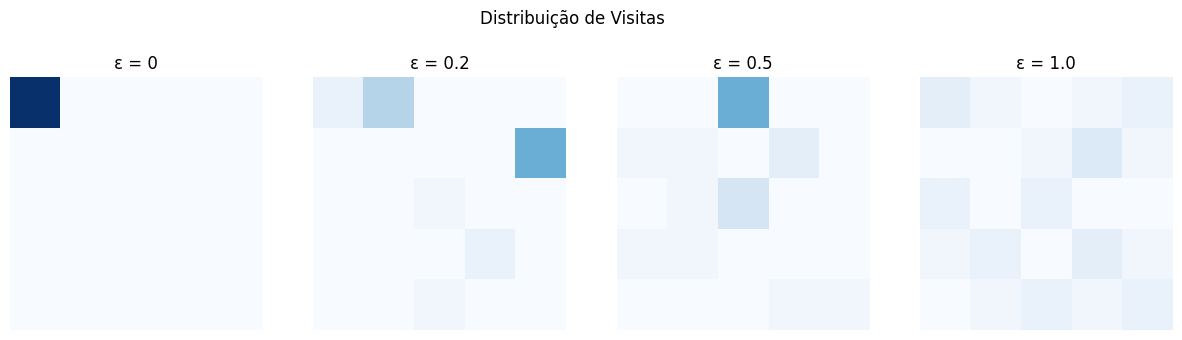

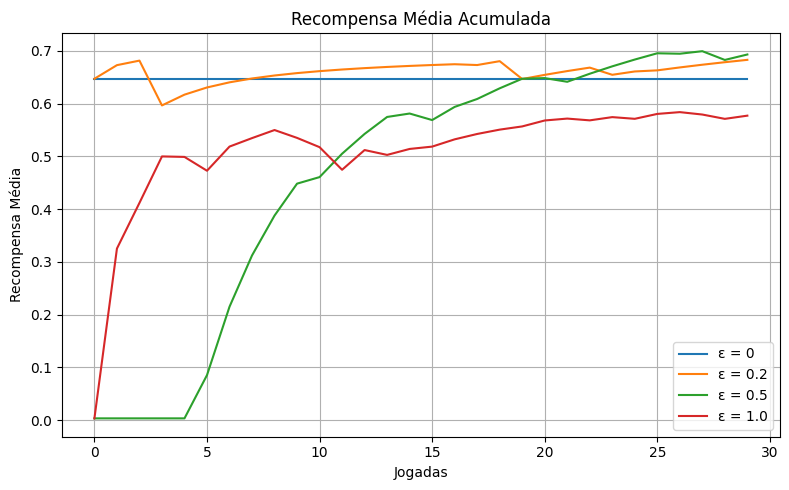

In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt

GRID_SIZE = 5
STEPS = 30

# Geração da grade de recompensas ocultas (
true_rewards = np.random.rand(GRID_SIZE, GRID_SIZE)

def select_cell(estimated, epsilon):
    """Escolhe uma célula com ε-greedy."""
    if random.random() < epsilon:
        return np.random.randint(0, GRID_SIZE), np.random.randint(0, GRID_SIZE)
    return np.unravel_index(np.argmax(estimated), estimated.shape)

def update_estimates(estimated, visits, i, j, reward):
    """Atualiza a média da recompensa estimada para a célula (i, j)."""
    visits[i, j] += 1
    n = visits[i, j]
    estimated[i, j] += (reward - estimated[i, j]) / n

def run_agent(epsilon):
    """Executa o agente para um valor de epsilon."""
    estimated = np.zeros((GRID_SIZE, GRID_SIZE))
    visits = np.zeros((GRID_SIZE, GRID_SIZE))
    total = 0
    avg_rewards = []

    for step in range(STEPS):
        i, j = select_cell(estimated, epsilon)
        reward = true_rewards[i, j]
        update_estimates(estimated, visits, i, j, reward)
        total += reward
        avg_rewards.append(total / (step + 1))

    return visits, total, avg_rewards

def plot_visits(results):
    fig, axs = plt.subplots(1, len(results), figsize=(15, 4))
    for idx, (eps, visits, _, _) in enumerate(results):
        axs[idx].imshow(visits, cmap='Blues', vmin=0, vmax=STEPS)
        axs[idx].set_title(f"ε = {eps}")
        axs[idx].axis('off')
    plt.suptitle("Distribuição de Visitas")
    plt.show()

def plot_rewards(results):
    plt.figure(figsize=(8, 5))
    for eps, _, _, rewards in results:
        plt.plot(rewards, label=f"ε = {eps}")
    plt.title("Recompensa Média Acumulada")
    plt.xlabel("Jogadas")
    plt.ylabel("Recompensa Média")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Execução para múltiplos valores de ε
epsilons = [0, 0.2, 0.5, 1.0]
results = [(eps, *run_agent(eps)) for eps in epsilons]

# Resultados
for eps, _, total, _ in results:
    print(f"ε = {eps:.1f} | Recompensa Total = {total:.3f}")

# Visualizações
plot_visits(results)
plot_rewards(results)


In [2]:
def softmax(x, tau=1.0):
    """Aplica softmax com temperatura tau."""
    x = x - np.max(x)  # estabilidade numérica
    exp_x = np.exp(x / tau)
    return exp_x / np.sum(exp_x)

def select_softmax_action(estimated, tau=1.0):
    """Seleciona uma célula usando softmax sobre as recompensas estimadas."""
    probs = softmax(estimated.flatten(), tau)
    index = np.random.choice(len(probs), p=probs)
    return np.unravel_index(index, estimated.shape)

def run_softmax_agent(tau):
    """Executa o agente com política softmax (parâmetro de temperatura tau)."""
    estimated = np.zeros((GRID_SIZE, GRID_SIZE))
    visits = np.zeros((GRID_SIZE, GRID_SIZE))
    total = 0
    avg_rewards = []

    for step in range(STEPS):
        i, j = select_softmax_action(estimated, tau)
        reward = true_rewards[i, j]
        update_estimates(estimated, visits, i, j, reward)
        total += reward
        avg_rewards.append(total / (step + 1))

    return visits, total, avg_rewards


In [ ]:
taus = [0.1, 0.5, 1.0, 2.0]
softmax_results = [(tau, *run_softmax_agent(tau)) for tau in taus]

for tau, _, total, _ in softmax_results:
    print(f"Tau = {tau:.1f} | Recompensa Total = {total:.3f}")

Tau = 0.1 | Recompensa Total = 22.931
Tau = 0.5 | Recompensa Total = 21.933
Tau = 1.0 | Recompensa Total = 18.664
Tau = 2.0 | Recompensa Total = 17.539


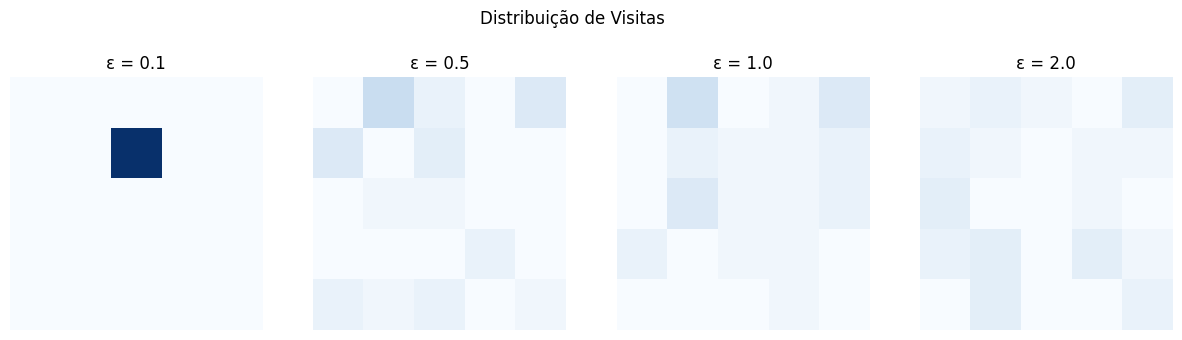

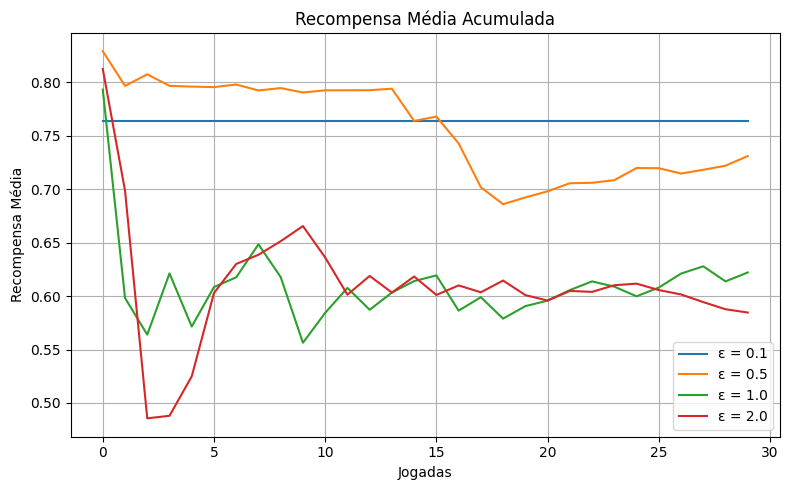

In [ ]:
plot_visits(softmax_results)
plot_rewards(softmax_results)

1. Onde no seu código ocorre a Exploration (exploração)?
Na função select_cell, quando a condição random.random() < epsilon é verdadeira, o agente escolhe uma célula aleatória da grade.

2. Onde no seu código ocorre a Exploitation (exploração do conhecimento)?
Na função select_cell, quando random.random() >= epsilon, o agente escolhe a célula com maior recompensa estimada usando np.argmax.

3. O que você observa com diferentes valores de ε:

    Quando ε = 0: o agente visita quase sempre a mesma célula. ε = 1: as visitas são distribuídas quase uniformemente. ε = 0.2 e ε = 0.5: há equilíbrio — o agente explora e também foca nas melhores células.

    Valor da recompensa média acumulada:

    Quando ε = 0.5 obteve a melhor média, pois equilibrou exploração e exploração do conhecimento. ε = 0 e ε = 1 tiveram desempenho inferior por serem extremos.

4. Qual configuração de ε apresentou melhor equilíbrio? Justifique.
A configuração ε = 0.5 apresentou o melhor equilíbrio. Ela permitiu que o agente descobrisse boas opções (exploração), mas também focasse nelas após identificá-las (exploração do conhecimento).